
===== LUNAR HOPPER LANDING REPORT =====
Touchdown Time      : 18.61 s
Landing Velocity    : 2.03 m/s
Landing Mass        : 1091.75 kg
Remaining Fuel      : 91.75 kg
Impact Force        : 7403.67 N
Condition           : NOMINAL LANDING


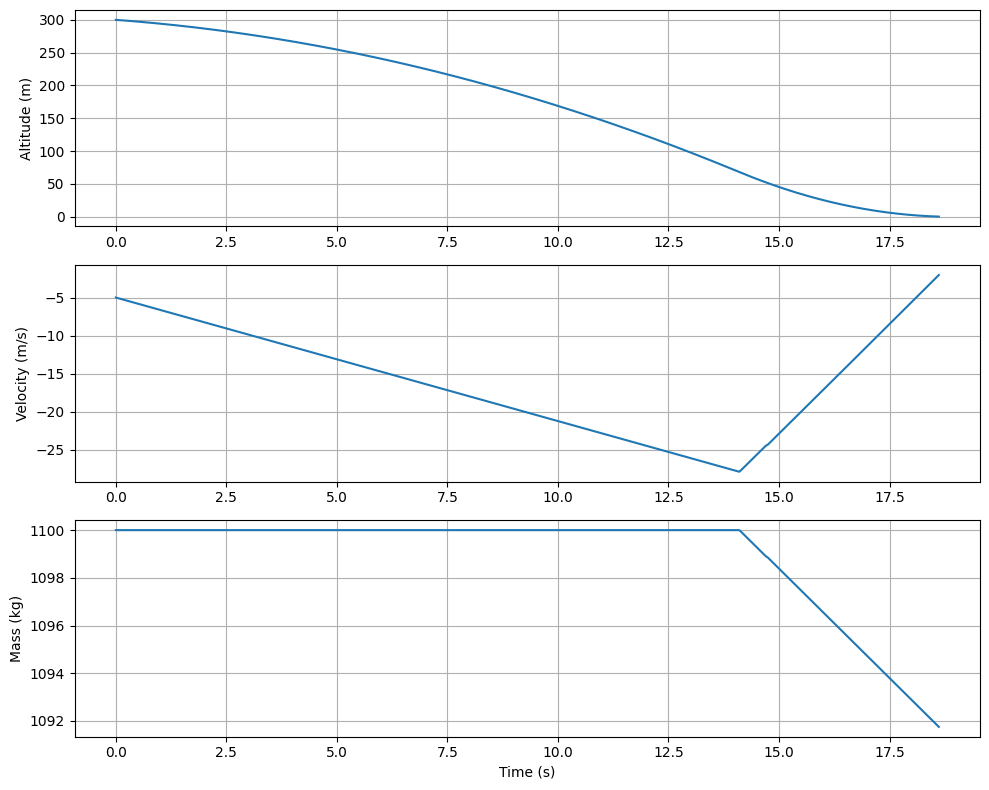

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =====================================================
#  ENVIRONMENT
# =====================================================

g_moon = 1.625      # Moon gravity (m/s^2)
g0 = 9.80665        # Earth gravity (for Isp equation)

# =====================================================
#  VEHICLE PARAMETERS
# =====================================================

wet_mass = 1100.0    # kg (initial mass with fuel)
dry_mass = 1000.0     # kg (mass after fuel depletion)

# Derived fuel mass
fuel_mass = wet_mass - dry_mass

# =====================================================
#  PROPULSION
# =====================================================

thrust = 8100.0      # N (constant engine thrust)
Isp = 450.0         # s (engine efficiency)

# Mass flow rate when engine is on
mdot = thrust / (Isp * g0)

# =====================================================
# INITIAL CONDITIONS
# =====================================================

h0 = 300.0          # altitude (m)
v0 = -5.0           # velocity (m/s)  (negative = downward)
m0 = wet_mass

# =====================================================
# IMPACT MODEL
# =====================================================

impact_duration = 0.3  # s (crash stopping time approximation)

# =====================================================
# DYNAMICS (UPWARD POSITIVE CONVENTION)
# =====================================================

def dynamics(t, state):
    h, v, m = state

    T = 0.0
    mdot_actual = 0.0

    # Calculate max possible deceleration
    # Acceleration = (Thrust / mass) - gravity
    max_deceleration = (thrust / m) - g_moon
    
    # Kinetic equation: distance needed to stop = v^2 / (2 * deceleration)
    # We use v**2, so it handles the negative velocity correctly
    stopping_distance = (v**2) / (2 * max_deceleration)

    # Trigger maximum thrust ONLY if we are at or below the safety stopping distance
    if m > dry_mass and h <= stopping_distance and v < 0:
        T = thrust
        mdot_actual = -mdot

    # Equations of motion
    dhdt = v
    dvdt = (T / m) - g_moon
    dmdt = mdot_actual

    return [dhdt, dvdt, dmdt]

# =====================================================
# TOUCHDOWN EVENT
# =====================================================

def touchdown(t, state):
    h, v, m = state
    return h

touchdown.terminal = True
touchdown.direction = -1

# =====================================================
#  SIMULATION
# =====================================================

initial_state = [h0, v0, m0]

solution = solve_ivp(
    dynamics,
    (0, 300),
    initial_state,
    events=touchdown,
    max_step=0.05
)

t = solution.t
h = solution.y[0]
v = solution.y[1]
m = solution.y[2]

# =====================================================
# 📊 RESULTS
# =====================================================

landing_velocity = abs(v[-1])
landing_mass = m[-1]

impact_force = landing_mass * landing_velocity / impact_duration

# =====================================================
# 🛬 LANDING CLASSIFICATION
# =====================================================

if landing_velocity < 1:
    condition = "SOFT LANDING"
elif landing_velocity < 3:
    condition = "NOMINAL LANDING"
elif landing_velocity < 5:
    condition = "HARD LANDING"
else:
    condition = "UNSAFE LANDING"

# =====================================================
# REPORT
# =====================================================

print("\n===== LUNAR HOPPER LANDING REPORT =====")
print(f"Touchdown Time      : {t[-1]:.2f} s")
print(f"Landing Velocity    : {landing_velocity:.2f} m/s")
print(f"Landing Mass        : {landing_mass:.2f} kg")
print(f"Remaining Fuel      : {max(0, landing_mass - dry_mass):.2f} kg")
print(f"Impact Force        : {impact_force:.2f} N")
print(f"Condition           : {condition}")

# =====================================================
# PLOTS
# =====================================================

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, h)
plt.ylabel("Altitude (m)")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, v)
plt.ylabel("Velocity (m/s)")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, m)
plt.ylabel("Mass (kg)")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()